<a href="https://colab.research.google.com/github/ggg2929/MagiskOnWSALocal/blob/main/Data_Twiter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Normalisasi**

In [1]:
# ===================== 🔧 INSTALASI LIBRARY =====================
!pip install -q fasttext Sastrawi pandas tqdm

# ===================== 📦 DOWNLOAD fastText Bahasa Indonesia =====================
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.bin.gz
!gzip -d cc.id.300.bin.gz  # Hasil = cc.id.300.bin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.1 MB/s eta 0:00:00


In [1]:
# ===================== 🔧 INSTALL (jalankan jika perlu) =====================
# !pip install fasttext pandas tqdm

# ===================== 📚 IMPORT LIBRARY =====================
import pandas as pd
import re
import fasttext
from tqdm import tqdm

# ===================== 📦 LOAD MODEL fastText =====================
print("📦 Memuat model fastText Bahasa Indonesia...")
ft_model = fasttext.load_model("cc.id.300.bin")  # Pastikan file ini tersedia

# ===================== 📁 BACA DATA KOMENTAR =====================
print("📁 Membaca file komentar...")
df = pd.read_csv("Data2.csv")  # Ganti jika nama file beda
df['full_text'] = df['full_text'].astype(str)

# ===================== 📌 FRASA PENTING (mapping sebelum proses per kata) =====================
frasa_khusus = {
    "ra mudeng": "tidak paham",
    "ora mudeng": "tidak paham",
    "ora ngerti": "tidak paham",
    "gak ngerti": "tidak paham",
    "nggak ngerti": "tidak paham",
    "gak mudeng": "tidak paham",
    "tidak ngerti": "tidak paham",
    "ngerti": "paham",
    "ngeh": "paham",
    "mudeng": "paham"
}

# ===================== 💡 CACHING UNTUK KATA UNIK =====================
cache_kata = {}

def normalisasi_otomatis_aman(word, threshold=0.75):
    word = word.lower()
    if word in cache_kata:
        return cache_kata[word]

    try:
        tetangga = ft_model.get_nearest_neighbors(word)
        for sim, near_word in tetangga:
            if sim >= threshold and near_word != word:
                cache_kata[word] = near_word
                return near_word
    except:
        pass
    cache_kata[word] = word
    return word

# ===================== 🔁 PRE-PROSES: BUAT KAMUS DARI SEMUA KATA UNIK =====================
print("🔍 Mengumpulkan semua kata unik...")
kata_unik = set()
for teks in df['full_text']:
    teks_bersih = teks.lower()
    for frasa, ganti in frasa_khusus.items():
        teks_bersih = teks_bersih.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', teks_bersih).split()
    kata_unik.update(tokens)

print(f"📊 Ditemukan {len(kata_unik)} kata unik. Memproses normalisasi dengan fastText...")

# Buat kamus normalisasi dari semua kata unik
normalisasi_dict = {}
for kata in tqdm(kata_unik, desc="⚙️ Normalisasi kata unik"):
    normalisasi_dict[kata] = normalisasi_otomatis_aman(kata)

# ===================== 🔁 PROSES NORMALISASI KOMENTAR MENGGUNAKAN KAMUS =====================
def normalisasi_kalimat_cepat(kalimat):
    kalimat = kalimat.lower()
    for frasa, ganti in frasa_khusus.items():
        kalimat = kalimat.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', kalimat).split()
    return ' '.join([normalisasi_dict.get(tok, tok) for tok in tokens])

print("🚀 Memulai proses normalisasi komentar...")
tqdm.pandas(desc="🔄 Normalisasi komentar")
df['komentar_normal'] = df['full_text'].progress_apply(normalisasi_kalimat_cepat)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("normalisasiTT.csv", index=False)
print("✅ Proses selesai! Hasil disimpan sebagai 'normalisasiTT.csv'")


📦 Memuat model fastText Bahasa Indonesia...
📁 Membaca file komentar...
🔍 Mengumpulkan semua kata unik...
📊 Ditemukan 5253 kata unik. Memproses normalisasi dengan fastText...


⚙️ Normalisasi kata unik: 100%|██████████| 5253/5253 [1:26:58<00:00,  1.01it/s]


🚀 Memulai proses normalisasi komentar...


🔄 Normalisasi komentar: 100%|██████████| 1010/1010 [00:00<00:00, 54284.41it/s]

✅ Proses selesai! Hasil disimpan sebagai 'normalisasiTT.csv'


**lihat hasil normalisasi**

In [3]:
import pandas as pd
from tabulate import tabulate

# Baca hasil CSV
df = pd.read_csv("normalisasiTT.csv")

# Tampilkan 20 kata paling sering dalam tabel rapi
print(tabulate(df.head(20), headers='keys', tablefmt='fancy_grid'))


╒════╤═══════════════════════╤════════════════════════════════╤══════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════╤═════════════════════════════════════════════════╤═══════════════════════════╤════════╤════════════╤═══════════════╤═══════════════╤═════════════════╤════════════════════════════════════════════════════╤═════════════════════╤════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│    │   conversation_

***Preprocessing***

In [4]:
!pip install sastrawi
!pip install nltk

In [5]:
# ===================== 🔧 INSTALASI =====================
# !pip install -q Sastrawi nltk

# ===================== 📚 IMPORT =====================
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# ===================== 🔧 SETUP STEMMER =====================
stemmer = StemmerFactory().create_stemmer()

# ===================== 📁 LOAD DATA NORMALISASI =====================
df = pd.read_csv("normalisasiTT.csv")  # dari langkah sebelumnya
df['komentar_normal'] = df['komentar_normal'].astype(str)

# ===================== 🧹 FUNGSI PREPROCESS NLP =====================
def preprocess_nlp(teks):
    teks = teks.lower()  # lower
    teks = re.sub(r'[^\w\s]', '', teks)  # hapus tanda baca
    tokens = word_tokenize(teks)  # tokenisasi
    tokens = [stemmer.stem(token) for token in tokens]  # stemming
    hasil = ' '.join(tokens)
    return hasil

# ===================== 🔁 TERAPKAN KE SEMUA KOMENTAR =====================
df['komentar_nlp'] = df['komentar_normal'].apply(preprocess_nlp)

# ===================== 🧼 HAPUS NaN JIKA ADA =====================
df.dropna(subset=['komentar_normal', 'komentar_nlp'], inplace=True)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("preprocessTT", index=False)
print("✅ File 'preprocessTT.csv' berhasil disimpan.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ File 'preprocessTT.csv' berhasil disimpan.


**alat deteksi konsentrasi**

In [20]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load file komentar yang sudah dipreprocessing (ganti path jika perlu)
df = pd.read_csv("preprocessTT")
df = df[df['komentar_nlp'].notna()].copy()
df['label_manual'] = None

# Setup
index = 0
output = widgets.Output()

# Tombol
btn_konsen = widgets.Button(description="✅ Konsentrasi", button_style='success')
btn_tdk_konsen = widgets.Button(description="❌ Tidak Konsentrasi", button_style='danger')
btn_skip = widgets.Button(description="⏭️ Lewati", button_style='warning')
btn_finish = widgets.Button(description="🛑 Selesai Sekarang", button_style='info')

# Tampilkan komentar ke layar
def show_comment():
    with output:
        clear_output(wait=True)
        print(f"Komentar {index+1}/{len(df)}:")
        print("\n", df.iloc[index]['komentar_nlp'])

# Fungsi aksi tombol
def on_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 1
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

def on_tdk_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 0
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()


def on_skip_clicked(b):
    global index
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

# Tombol selesai manual
def on_finish_clicked(b):
    save_and_finish()

# Simpan ke CSV setelah selesai
def save_and_finish():
    path = "preprocessTT_labeled_manual.csv"
    df.to_csv(path, index=False)
    with output:
        clear_output()
        print(f"✅ Selesai! Data disimpan di: {path}")

# Hubungkan tombol ke fungsi
tn = [
    (btn_konsen, on_konsen_clicked),
    (btn_tdk_konsen, on_tdk_konsen_clicked),
    (btn_skip, on_skip_clicked),
    (btn_finish, on_finish_clicked)
]
for btn, func in tn:
    btn.on_click(func)

# Tampilkan awal
show_comment()
display(widgets.HBox([btn_konsen, btn_tdk_konsen, btn_skip, btn_finish]))
display(output)


Output()

**labeling**

In [21]:
!pip install qgrid
!pip install itables

In [22]:
# ===========================
# 🔍 TRAINING MODEL DARI 8 LABELING MANUAL + PREDIKSI SEMUA DATA
# ===========================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import joblib

# 1. Load semua data
df_all = pd.read_csv("preprocessTT_labeled_manual.csv")

# 2. Pisahkan data berlabel (label_manual tidak kosong) → hanya 8 data ini untuk training
df_train = df_all.dropna(subset=['komentar_nlp', 'label_manual']).copy()
df_train['label_manual'] = df_train['label_manual'].astype(int)

# 3. Pisahkan komentar NLP dari semua data (termasuk yang tidak dilabeli)
all_komentar = df_all['komentar_nlp']

# 4. Vectorisasi TF-IDF berdasarkan data training
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(df_train['komentar_nlp'])
y_train = df_train['label_manual']

# 5. Train model dari 8 data manual
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. Simpan model & vectorizer
joblib.dump(model, "model_konsentrasi.pkl")
joblib.dump(vectorizer, "vectorizer_konsentrasi.pkl")
print("\n✅ Model dan vectorizer berhasil disimpan!")

# 7. Prediksi semua komentar dari seluruh dataset
all_tfidf = vectorizer.transform(all_komentar)
df_all['prediksi_konsentrasi'] = model.predict(all_tfidf)
df_all['kategori'] = df_all['prediksi_konsentrasi'].map({1: 'Konsentrasi', 0: 'Tidak Konsentrasi'})

# 8. Simpan hasil lengkap
df_all.to_csv("preprocessTT.csv", index=False)
print("\n📁 File dengan prediksi disimpan di: preprocessTT.csv")

# 9. Tampilkan semua data
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
display(df_all[['komentar_normal', 'komentar_nlp', 'kategori']])



✅ Model dan vectorizer berhasil disimpan!

📁 File dengan prediksi disimpan di: preprocessTT.csv


,komentar_normal,komentar_nlp,kategori
0,ouhhhh nono ill say balajar sama Ayah Ya sayanglah dia kalkulus. dapet-dapet b menerus pas kuliahnya,ouhhhh nono ill say balajar sama ayah ya sayang dia kalkulus dapetdapet b terus pas kuliah,Konsentrasi
1,ismailfahmi sebagi yag pernah- balajar It 4 Tahun untuki level2 sekolahsekolah kematangannya balajar logika-logika sangatlah dibutuhkan Saya sendiri Di sekolahsekolah negri daerah-daerah sangatlah sulit pas kuliahnya Karena nggak faham logika-logika matematikan Apalagi pas balajar kalkulus. matematikan diskrit. dasar algoritma-algoritma,ismailfahmi bagi yag pernah balajar it 4 tahun untuk level2 sekolahsekolah matang balajar logikalogika sangat butuh saya sendiri di sekolahsekolah negri daerahdaerah sangat sulit pas kuliah karena nggak faham logikalogika matematikan apalagi pas balajar kalkulus matematikan diskrit dasar algoritmaalgoritma,Tidak Konsentrasi
2,sianturi dahulu waktu.Waktu sma Nilai gua jelek bangetz serta banya yag gax gua faham sama yag namannya matematikan trus pas kuliahnya kepilih jurusannya tehnik mesin Padahal pilihannya keempat serta yaa Nilai gua belum jelek kalkulus. 2 ajah Nilai kasian Dosen gua tpi pas gua mw kerjanya gua balajar,sianturi dahulu waktuwaktu sma nilai gua jelek bangetz serta banya yag gax gua faham sama yag namannya matematikan trus pas kuliah pilih jurus tehnik mesin padahal pilih empat serta yaa nilai gua belum jelek kalkulus 2 ajah nilai kasi dosen gua tpi pas gua mw kerja gua balajar,Tidak Konsentrasi
3,teringat kuliahnya kalkulus. amp ale,ingat kuliah kalkulus amp ale,Tidak Konsentrasi
4,Sbarra saat kuliahnya balajar kalkulus. jg terpenting lulus-lulus ajah Biar Tahun depan gk ketemu-ketemu lagi jd gk bener2x faham tp apa jg dipelajari,sbarra saat kuliah balajar kalkulus jg penting luluslulus ajah biar tahun depan gk ketemuketemu lagi jd gk bener2x faham tp apa jg ajar,Tidak Konsentrasi
5,Sbarra matematikan kelas 1112 integral serta diferensial dilanjut kalkulus. Di masa-masa kuliahnya balajar sangat buat lulus-lulus ajah,sbarra matematikan kelas 1112 integral serta diferensial lanjut kalkulus di masamasa kuliah balajar sangat buat luluslulus ajah,Konsentrasi
6,Ya yahhhhh kuliahnya gk kepegang plisss kalkulus. pas balajar enak pas kuis. KRHYYFGTRYWZRS-UHFFFAOYSA-M,ya yahhhhh kuliah gk pegang plisss kalkulus pas balajar enak pas kuis krhyyfgtrywzrsuhfffaoysam,Konsentrasi
7,yakin ga yakin Gue pernah- dapet-dapet tugas-tugas kalkulus. pas kuliahnya Ngerjainnya dari playlistnya alter setelah Gue kenal-kenal alter as komunitasnya balajar iyyah sebenernya cuma kalkulus. akhir bgt Tapi Siapa sangka 95 wkwkwk,yakin ga yakin gue pernah dapetdapet tugastugas kalkulus pas kuliah ngerjainnya dari playlistnya alter telah gue kenalkenal alter as komunitas balajar iyyah sebenernya cuma kalkulus akhir bgt tapi siapa sangka 95 wkwkwk,Konsentrasi
8,Jangan lewatkan kesempata untuki bergabung serta balajar langsung bersama-sama Dosen tersedia 4 mata.Mata kuliahnya kalkulus. iii aljabar. linier elementer 3 metoda numeriknya metoda peramalan metoda matematis 2 metoda matematis 3,jangan lewat kesempata untuk gabung serta balajar langsung bersamasama dosen sedia 4 matamata kuliah kalkulus iii aljabar linier elementer 3 metoda numerik metoda amal metoda matematis 2 metoda matematis 3,Konsentrasi
9,mengapa kesannya kalkulus. lebih-Iebih gampang dimengerti dibandingkan aljabar. linier Karena porsinya waktu.Waktu balajar kalkulus. lebih-Iebih banya baikdi Di sekolahsekolah ataupun kuliahnya,mengapa kesan kalkulus lebihiebih gampang erti banding aljabar linier karena porsi waktuwaktu balajar kalkulus lebihiebih banya baikdi di sekolahsekolah atau kuliah,Konsentrasi


=== Jumlah Data per Kategori ===
kategori
Konsentrasi          889
Tidak Konsentrasi    121
Name: count, dtype: int64


<ipython-input-23-3481208622>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='kategori', palette='Set2')


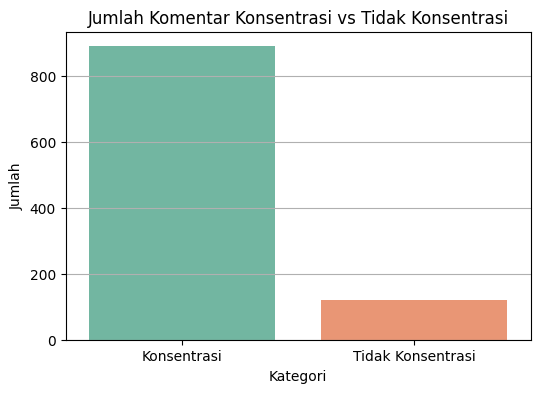


=== Kata Teratas - Konsentrasi ===


,Kata,Frekuensi
0,balajar,988
1,kalkulus,954
2,kuliah,942
3,sebut,265
4,rw,251
5,di,228
6,serta,211
7,2,170
8,matematikan,166
9,aku,165



=== Kata Teratas - Tidak Konsentrasi ===


,Kata,Frekuensi
0,kuliah,135
1,balajar,132
2,kalkulus,131
3,jg,79
4,ajah,46
5,gk,45
6,sebut,37
7,gua,33
8,matematikan,31
9,pas,30


<ipython-input-23-3481208622>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')


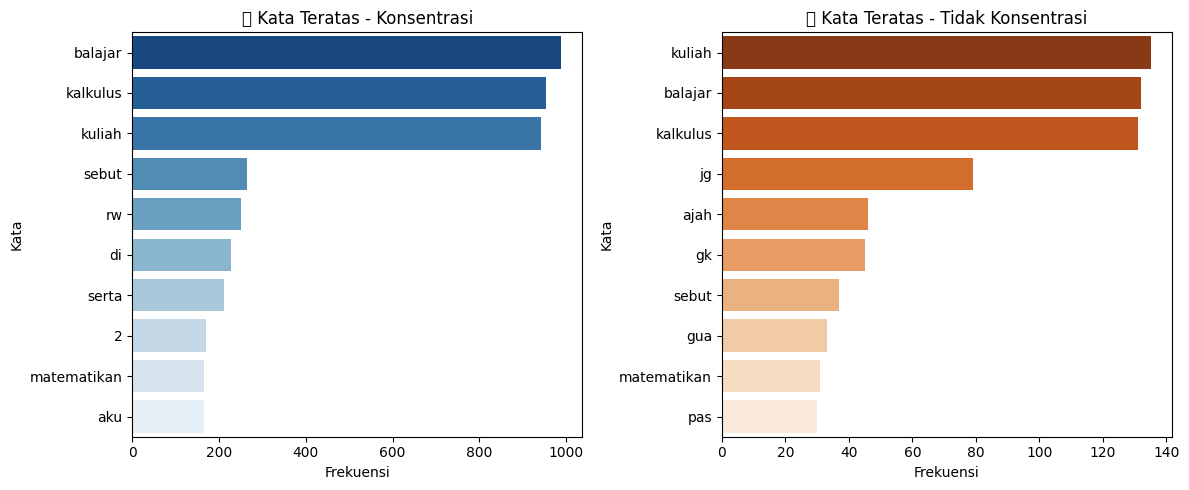

In [23]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung jumlah kategori
jumlah_kategori = df_all['kategori'].value_counts()
print("=== Jumlah Data per Kategori ===")
print(jumlah_kategori)

# 2. Tampilkan diagram jumlah kategori
plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x='kategori', palette='Set2')
plt.title("Jumlah Komentar Konsentrasi vs Tidak Konsentrasi")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.grid(axis='y')
plt.show()

# 3. Tokenisasi komentar_nlp → pisahkan per kategori
df_all['tokens'] = df_all['komentar_nlp'].astype(str).str.split()

# Ambil token per kategori
tokens_konsentrasi = df_all[df_all['kategori'] == 'Konsentrasi']['tokens'].sum()
tokens_tdk_konsentrasi = df_all[df_all['kategori'] == 'Tidak Konsentrasi']['tokens'].sum()

# Hitung kata paling sering muncul
# Check if the token list is not empty before using Counter
top_konsentrasi = Counter(tokens_konsentrasi).most_common(10) if tokens_konsentrasi else []
top_tdk_konsentrasi = Counter(tokens_tdk_konsentrasi).most_common(10) if tokens_tdk_konsentrasi else []

# Buat dataframe
df_konsentrasi = pd.DataFrame(top_konsentrasi, columns=['Kata', 'Frekuensi'])
df_tdk_konsentrasi = pd.DataFrame(top_tdk_konsentrasi, columns=['Kata', 'Frekuensi'])

# 4. Tampilkan tabel
print("\n=== Kata Teratas - Konsentrasi ===")
display(df_konsentrasi)

print("\n=== Kata Teratas - Tidak Konsentrasi ===")
display(df_tdk_konsentrasi)

# 5. Diagram kata teratas
plt.figure(figsize=(12, 5))

# Konsentrasi
plt.subplot(1, 2, 1)
sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')
plt.title("🔵 Kata Teratas - Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

# Tidak Konsentrasi
plt.subplot(1, 2, 2)
sns.barplot(data=df_tdk_konsentrasi, y='Kata', x='Frekuensi', palette='Oranges_r')
plt.title("🟠 Kata Teratas - Tidak Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.tight_layout()
plt.show()

**Pelatihan model**

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8342 - loss: 0.5523 - val_accuracy: 0.8889 - val_loss: 0.3569
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8619 - loss: 0.4158 - val_accuracy: 0.8889 - val_loss: 0.3451
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8800 - loss: 0.3440 - val_accuracy: 0.8889 - val_loss: 0.3373
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8650 - loss: 0.3011 - val_accuracy: 0.8889 - val_loss: 0.3082
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9087 - loss: 0.1833 - val_accuracy: 0.8889 - val_loss: 0.2993
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9970 - loss: 0.0600 - val_accuracy: 0.8889 - val_loss: 0.2958
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 0.0174 - val_accuracy: 0.8889 - val_loss: 0.3217
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.8889 - 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

=== Classification Report ===
                   precision    recall  f1-score   support

Tidak Konsentrasi       0.75      0.12      0.21        24
      Konsentrasi       0.89      0.99      0.94       178

         accuracy                           0.89       202
        macro avg       0.82      0.56      0.58       202
     weighted avg       0.88      0.89      0.86       202


✅ Akurasi: 89.11 %


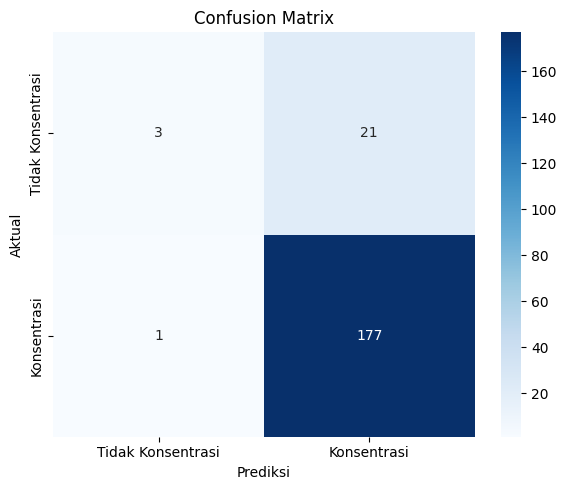

In [24]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('preprocessTT.csv')
df = df.dropna(subset=['full_text', 'prediksi_konsentrasi'])

# 2. Label dan data teks
texts = df['full_text'].values
labels = df['prediksi_konsentrasi'].values

# 3. Tokenisasi teks
max_words = 10000  # jumlah maximal kata
max_len = 100      # panjang sequence (bisa disesuaikan)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)

# 4. Label untuk binary classification (0 dan 1)
y = labels

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Bangun model CNN
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # output 1 node dengan sigmoid untuk binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# 7. Latih model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight={0: 1, 1: 1}  # Bisa diatur sesuai kebutuhan
)

# 8. Evaluasi
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n=== Classification Report ===")

unique_labels_test = np.unique(y_test)

if len(unique_labels_test) < 2:
    print("Note: Only one class is present in the test set due to limited training data. Classification report is not applicable.")
    # Manually calculate and print accuracy if only one class is present
    print(f"✅ Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f} %")
else:
    target_names = ['Tidak Konsentrasi', 'Konsentrasi']
    # Filter target_names based on unique labels in y_test
    filtered_target_names = [name for i, name in enumerate(target_names) if i in unique_labels_test]
    print(classification_report(y_test, y_pred, target_names=filtered_target_names))
    print("\n✅ Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Ensure confusion matrix labels match the unique labels in y_test
cm = confusion_matrix(y_test, y_pred, labels=unique_labels_test)
labels_cm = [name for i, name in enumerate(['Tidak Konsentrasi', 'Konsentrasi']) if i in unique_labels_test]


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_cm, yticklabels=labels_cm)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**kesimpulan**

In [26]:
# === Analisis Konsentrasi Otomatis ===
total_konsentrasi = jumlah_kategori.get('Konsentrasi', 0)
total_tidak_konsentrasi = jumlah_kategori.get('Tidak Konsentrasi', 0)
total_data = total_konsentrasi + total_tidak_konsentrasi

persen_konsentrasi = (total_konsentrasi / total_data) * 100 if total_data else 0
persen_tidak = (total_tidak_konsentrasi / total_data) * 100 if total_data else 0

print(f"\n📊 Total Data: {total_data}")
print(f"✅ Konsentrasi: {total_konsentrasi} data ({persen_konsentrasi:.2f}%)")
print(f"❌ Tidak Konsentrasi: {total_tidak_konsentrasi} data ({persen_tidak:.2f}%)")
print("\n--- KESIMPULAN ---")

if persen_konsentrasi > 80:
    print("✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Twiter.")
    print("💡 Hal ini menunjukkan bahwa media Twiter efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.")
elif persen_konsentrasi > 50:
    print("🔍 Sebagian besar mahasiswa cukup konsentrasi belajar melalui media Twiter.")
    print("💡 Media ini cukup membantu namun perlu evaluasi untuk menjangkau semua mahasiswa.")
else:
    print("⚠️ Mayoritas mahasiswa kurang konsentrasi saat belajar menggunakan media Twiter.")
    print("❗ Disarankan mencari media atau metode pembelajaran lain yang lebih efektif.")



📊 Total Data: 1010
✅ Konsentrasi: 889 data (88.02%)
❌ Tidak Konsentrasi: 121 data (11.98%)

--- KESIMPULAN ---
✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Twiter.
💡 Hal ini menunjukkan bahwa media Twiter efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.
